# Classification Analysis in Python- ISLP Chapter 4
**Annalise Banda | STA 6543**

# Q13
This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically significant? If so,
which ones?

(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.

(d) Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

(e) Repeat (d) using LDA.

(f) Repeat (d) using QDA.

(g) Repeat (d) using KNN with K =1.

(h) Repeat (d) using naive Bayes.

(i) Which of these methods appears to provide the best results on
this data?

(j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the
methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held
out data. Note that you should also experiment with values for
K in the KNN classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


### (a) Numerical and Graphical Summaries of the Weekly Data

In [2]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [3]:
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


In [4]:
Weekly['Direction'].value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

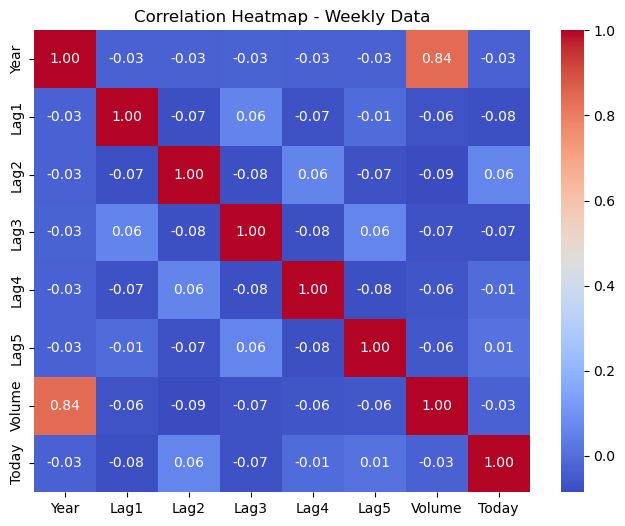

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(Weekly.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Weekly Data')
plt.show()

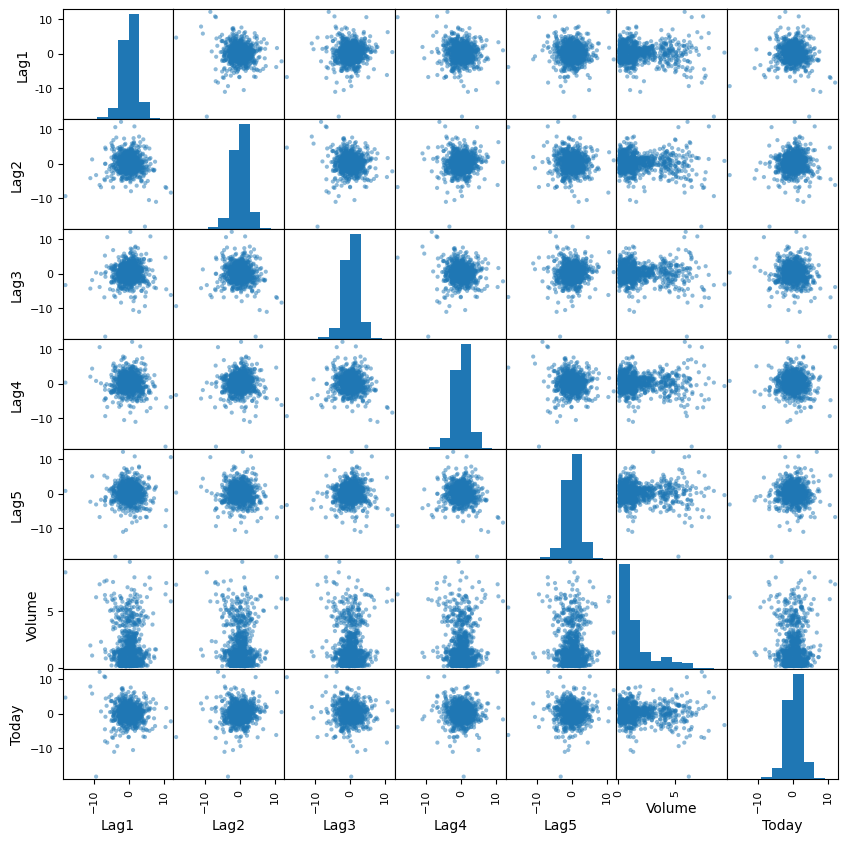

In [6]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']],
    figsize=(10,10),
    diagonal='hist'
)

plt.show()

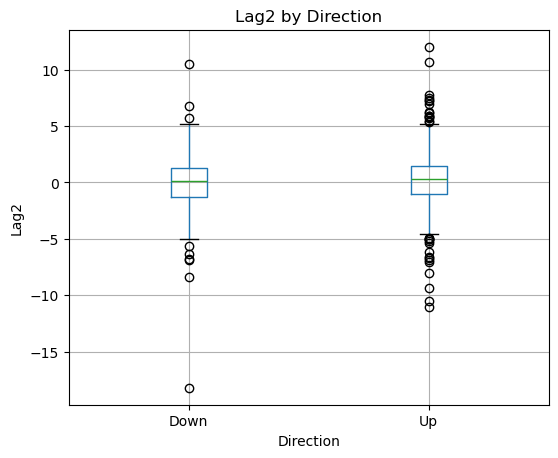

In [7]:
Weekly.boxplot(column='Lag2', by='Direction', figsize=(6,5))

plt.title('Lag2 by Direction')
plt.suptitle('')
plt.xlabel('Direction')
plt.ylabel('Lag2')
plt.show()

The Weekly dataset contains 1,089 observations collected from 1990 to 2010. There are slightly more Up weeks than Down weeks. The correlation matrix indicates that most lag variables have weak correlations with one another and with the response. The most noticeable trend is that trading Volume steadily increases over time, while the weekly returns do not display strong visual patterns. Overall, there does not appear to be a strong linear relationship between the lag variables and market direction. 

### (b) Logistic Regression with all Predictors

In [8]:
Weekly['Direction_binary'] = Weekly['Direction'].map({
    'Down': 0,
    'Up': 1
})

In [9]:
import statsmodels.api as sm

X = Weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X = sm.add_constant(X) 
y = Weekly['Direction_binary']

logit_model = sm.Logit(y, X)
results = logit_model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                0.006580
Time:                        10:49:07   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

Out of the five lags and Volume, only **Lag2** is statistically significant 
($p = 0.030$, below the $\alpha = 0.05$ threshold). Its coefficient is positive 
($\beta_{Lag2} = 0.0584$), meaning weeks where the market was up two weeks ago 
are slightly more likely to be followed by an up week now, though this is a 
fairly weak effect. The Pseudo $R^2$ is only $0.0066$, which is very low. This 
indicates the model overall doesn't explain much of the variation in Direction, 
even though Lag2 is "statistically significant".

### (c) Confusion Matrix and Overall Fraction of Correct Predictions

In [10]:
predicted_probs = results.predict(X)
predicted_labels = (predicted_probs > 0.5).astype(int)

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y, predicted_labels)
print(conf_matrix)

[[ 54 430]
 [ 48 557]]


In [12]:
accuracy = (predicted_labels == y).mean()
print(f"Overall accuracy: {accuracy:.4f}")

Overall accuracy: 0.5611


The confusion matrix shows that the logistic regression model correctly predicted 611 out of 1,089 weeks (overall accuracy $= 0.5611$, or about $56.1\%$). However, the matrix reveals a strong imbalance in how the model makes errors. Of the 484 weeks the market actually went Down, the model incorrectly predicted Up in 430 of them — a false positive rate of about $88.8\%$. In contrast, of the 605 weeks the market actually went Up, the model correctly predicted Up in 557 of them, missing only 48 (a false negative rate of about $7.9\%$).

This pattern suggests the model is heavily biased toward predicting "Up" regardless of the actual predictors, rather than genuinely distinguishing between Up and Down weeks. In fact, a naive strategy of always predicting "Up" would 
achieve $605/1089 = 55.6\%$ accuracy, nearly identical to the model's performance. 
This confirms what the low Pseudo $R^2$ in part (b) suggested: the full model with all six predictors provides little real improvement over simply guessing the majority class.

### (d) Logistic Regression with Training Data from 1990-2008, Lag2 only, Tested on 2009-2010

In [13]:
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

print(train.shape, test.shape)

(985, 10) (104, 10)


In [14]:
X_train = sm.add_constant(train[['Lag2']])
y_train = train['Direction_binary']

X_test = sm.add_constant(test[['Lag2']])
y_test = test['Direction_binary']

logit_model2 = sm.Logit(y_train, X_train)
results2 = logit_model2.fit()
print(results2.summary())

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                0.003076
Time:                        10:49:08   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.

In [15]:
predicted_probs2 = results2.predict(X_test)
predicted_labels2 = (predicted_probs2 > 0.5).astype(int)

In [16]:
conf_matrix2 = confusion_matrix(y_test, predicted_labels2)
print(conf_matrix2)

accuracy2 = (predicted_labels2 == y_test).mean()
print(f"Test accuracy: {accuracy2:.4f}")

[[ 9 34]
 [ 5 56]]
Test accuracy: 0.6250


Using Lag2 as the sole predictor and testing on the held-out 2009–2010 data, the logistic regression model achieved a test accuracy of $62.5\%$, an improvement over both the full model from part (c) ($56.1\%$) and the naive baseline of always predicting "Up" ($58.7\%$ for this test period). The confusion matrix shows the model still favors predicting "Up," correctly identifying 56 of 61 actual Up weeks, but misclassifying 34 of 43 actual Down weeks. This suggests that while Lag2 carries some genuine predictive signal consistent with its statistical significance in part (b), the model still 
struggles to distinguish Down weeks from Up weeks.

### (e) Linear Discriminant Analysis (LDA)

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_train_lda = train[['Lag2']]
y_train_lda = train['Direction_binary']

X_test_lda = test[['Lag2']]
y_test_lda = test['Direction_binary']

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_lda, y_train_lda)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [18]:
predicted_labels_lda = lda_model.predict(X_test_lda)

In [19]:
conf_matrix_lda = confusion_matrix(y_test_lda, predicted_labels_lda)
print(conf_matrix_lda)

accuracy_lda = (predicted_labels_lda == y_test_lda).mean()
print(f"LDA Test accuracy: {accuracy_lda:.4f}")

[[ 9 34]
 [ 5 56]]
LDA Test accuracy: 0.6250


LDA produced an identical confusion matrix and test accuracy ($62.5\%$) to the logistic regression model in part (d). This is expected: with a single predictor (Lag2), both LDA and logistic regression estimate similar linear decision boundaries between the two classes, so their predictions align closely in this case. This consistency also reinforces that any gains from Lag2 over the naive 
baseline are a real, if modest, effect rather than an artifact of a particular modeling method.

### (f) Quadratic Discriminant Analysis (QDA)

In [20]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train_lda, y_train_lda)  # reusing the same X_train/y_train from LDA

predicted_labels_qda = qda_model.predict(X_test_lda)

conf_matrix_qda = confusion_matrix(y_test_lda, predicted_labels_qda)
print(conf_matrix_qda)

accuracy_qda = (predicted_labels_qda == y_test_lda).mean()
print(f"QDA Test accuracy: {accuracy_qda:.4f}")

[[ 0 43]
 [ 0 61]]
QDA Test accuracy: 0.5865


QDA achieved a test accuracy of $58.65\%$, lower than both logistic regression and LDA. Notably, the confusion matrix shows QDA predicted "Up" for every single test observation, never predicting "Down" at all. This means QDA's accuracy is essentially identical to the naive baseline of always guessing the majority class. This suggests that the added flexibility of QDA's quadratic decision boundary is not helpful here, with only one predictor (Lag2) and limited 
class separation in the training data, QDA fails to find a useful region to classify observations as "Down," making it the weakest of the three methods so far.

### (g) K-Nearest Neighbors with K=1

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train_lda, y_train_lda)  # reusing same train/test data as LDA/QDA

predicted_labels_knn = knn_model.predict(X_test_lda)

conf_matrix_knn = confusion_matrix(y_test_lda, predicted_labels_knn)
print(conf_matrix_knn)

accuracy_knn = (predicted_labels_knn == y_test_lda).mean()
print(f"KNN (K=1) Test accuracy: {accuracy_knn:.4f}")

[[22 21]
 [31 30]]
KNN (K=1) Test accuracy: 0.5000


KNN with $K=1$ achieved a test accuracy of only $50\%$, the weakest performance among the methods tried so far, and no better than random guessing. Unlike LDA and QDA, this model predicted a more balanced mix of Up and Down outcomes, but 
that balance did not translate into better accuracy. This is consistent with $K=1$ being the highest-variance version of KNN: predictions rely on a single nearest neighbor in the training data, making the model highly sensitive to 
noise. Given the weak separation between classes observed in part (a), this sensitivity leads to unreliable predictions on the held-out test set.

### (h) Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_lda, y_train_lda)

predicted_labels_nb = nb_model.predict(X_test_lda)

conf_matrix_nb = confusion_matrix(y_test_lda, predicted_labels_nb)
print(conf_matrix_nb)

accuracy_nb = (predicted_labels_nb == y_test_lda).mean()
print(f"Naive Bayes Test accuracy: {accuracy_nb:.4f}")

[[ 0 43]
 [ 0 61]]
Naive Bayes Test accuracy: 0.5865


Naive Bayes produced the same result as QDA: a test accuracy of $58.65\%$, with every test observation classified as "Up." This mirrors QDA's behavior because, 
with a single predictor, Naive Bayes's class-conditional Gaussian estimates behave similarly to QDA's. The heavy overlap between Up and Down weeks' Lag2 values, noted in part (a), again leads the model to default to the majority class.

### (i) Comparing All Five Methods

In [23]:
results_summary = pd.DataFrame({
    'Method': ['Logistic Regression', 'LDA', 'QDA', 'KNN (K=1)', 'Naive Bayes'],
    'Test Accuracy': [accuracy2, accuracy_lda, accuracy_qda, accuracy_knn, accuracy_nb]
})

results_summary['Test Accuracy'] = results_summary['Test Accuracy'].round(4)
results_summary = results_summary.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results_summary

,Method,Test Accuracy
0,Logistic Regression,0.6250
1,LDA,0.6250
2,QDA,0.5865
3,Naive Bayes,0.5865
4,KNN (K=1),0.5000


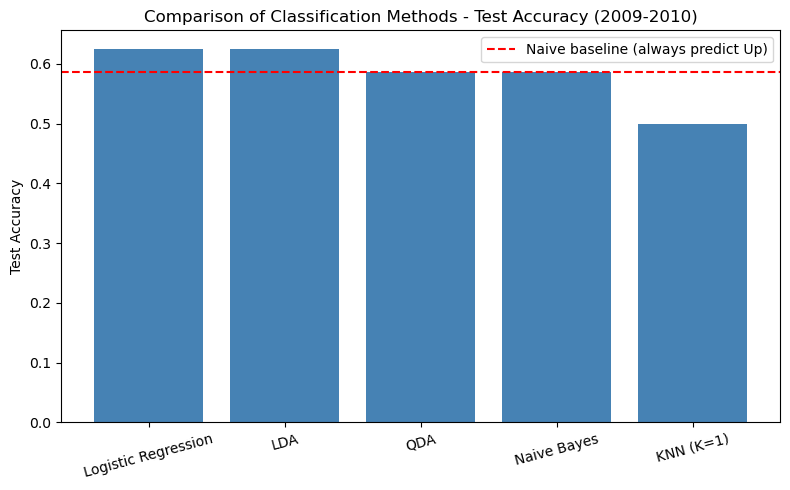

In [24]:
plt.figure(figsize=(8,5))
plt.bar(results_summary['Method'], results_summary['Test Accuracy'], color='steelblue')
plt.axhline(y=61/104, color='red', linestyle='--', label='Naive baseline (always predict Up)')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Classification Methods - Test Accuracy (2009-2010)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

Comparing all five classification methods on the held-out 2009–2010 data, logistic regression and LDA performed best, both achieving $62.5\%$ test accuracy. QDA and Naive Bayes tied for third at $58.65\%$, though neither outperformed the naive baseline of always predicting "Up." 
KNN with $K=1$ performed worst at $50\%$, no better than random guessing. Overall, the simpler, linear methods (logistic regression and LDA) provided the best 
results on this dataset, suggesting that with only a weak, roughly linear signal in Lag2, added model flexibility (as in QDA and KNN) does not help and can even hurt out-of-sample performance.

### (j) Experimentation

In [25]:
X_train_j1 = sm.add_constant(train[['Lag1', 'Lag2']])
X_test_j1 = sm.add_constant(test[['Lag1', 'Lag2']])

logit_j1 = sm.Logit(y_train, X_train_j1).fit()
pred_j1 = (logit_j1.predict(X_test_j1) > 0.5).astype(int)
acc_j1 = (pred_j1 == y_test).mean()
print(f"Logistic (Lag1+Lag2) accuracy: {acc_j1:.4f}")

Optimization terminated successfully.
         Current function value: 0.683735
         Iterations 4
Logistic (Lag1+Lag2) accuracy: 0.5769


In [26]:
train_j2 = train.copy()
test_j2 = test.copy()
train_j2['Lag1_Lag2'] = train_j2['Lag1'] * train_j2['Lag2']
test_j2['Lag1_Lag2'] = test_j2['Lag1'] * test_j2['Lag2']

X_train_j2 = sm.add_constant(train_j2[['Lag2', 'Lag1_Lag2']])
X_test_j2 = sm.add_constant(test_j2[['Lag2', 'Lag1_Lag2']])

logit_j2 = sm.Logit(y_train, X_train_j2).fit()
pred_j2 = (logit_j2.predict(X_test_j2) > 0.5).astype(int)
acc_j2 = (pred_j2 == y_test).mean()
print(f"Logistic (Lag2 + Lag1*Lag2 interaction) accuracy: {acc_j2:.4f}")

Optimization terminated successfully.
         Current function value: 0.685139
         Iterations 4
Logistic (Lag2 + Lag1*Lag2 interaction) accuracy: 0.5865


In [27]:
train_j3 = train.copy()
test_j3 = test.copy()
train_j3['Lag2_sq'] = train_j3['Lag2'] ** 2
test_j3['Lag2_sq'] = test_j3['Lag2'] ** 2

X_train_j3 = train_j3[['Lag2', 'Lag2_sq']]
X_test_j3 = test_j3[['Lag2', 'Lag2_sq']]

lda_j3 = LinearDiscriminantAnalysis()
lda_j3.fit(X_train_j3, y_train)
pred_j3 = lda_j3.predict(X_test_j3)
acc_j3 = (pred_j3 == y_test).mean()
print(f"LDA (Lag2 + Lag2^2) accuracy: {acc_j3:.4f}")

LDA (Lag2 + Lag2^2) accuracy: 0.6154


In [28]:
knn_results = []
for k in [1, 3, 5, 7, 9, 15, 25, 50]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_lda, y_train_lda)  # Lag2 only, from part (g)
    pred_k = knn.predict(X_test_lda)
    acc_k = (pred_k == y_test_lda).mean()
    knn_results.append({'K': k, 'Accuracy': acc_k})

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,K,Accuracy
0,1,0.500000
1,3,0.548077
2,5,0.538462
3,7,0.548077
4,9,0.548077
5,15,0.586538
6,25,0.548077
7,50,0.557692


In [29]:
# Build a summary table of all part (j) experiments
j_results = pd.DataFrame({
    'Attempt': ['Lag2 only (Logistic/LDA)', 'Lag1+Lag2 (Logistic)', 
                'Lag2 + Lag1×Lag2 (Logistic)', 'Lag2 + Lag2² (LDA)', 
                'Best KNN (K=15)'],
    'Test Accuracy': [accuracy2, acc_j1, acc_j2, acc_j3, 0.586538]
})

j_results['Test Accuracy'] = j_results['Test Accuracy'].round(4)
j_results = j_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

j_results.style.hide(axis='index')

Attempt,Test Accuracy
Lag2 only (Logistic/LDA),0.625000
Lag2 + Lag2² (LDA),0.615400
Lag2 + Lag1×Lag2 (Logistic),0.586500
Best KNN (K=15),0.586500
Lag1+Lag2 (Logistic),0.576900


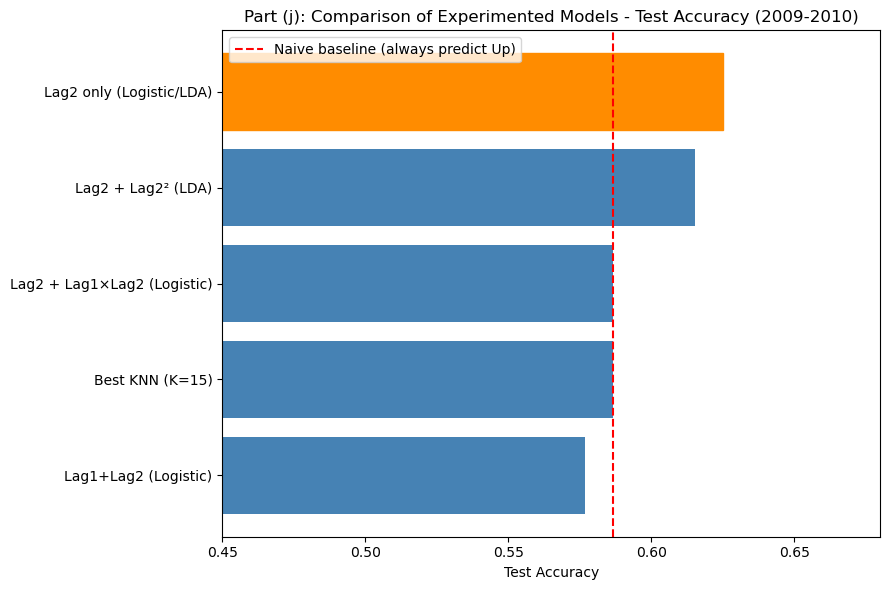

In [30]:
plt.figure(figsize=(9,6))
bars = plt.barh(j_results['Attempt'], j_results['Test Accuracy'], color='steelblue')

best_idx = j_results['Test Accuracy'].idxmax()
bars[best_idx].set_color('darkorange')

plt.axvline(x=61/104, color='red', linestyle='--', label='Naive baseline (always predict Up)')
plt.xlabel('Test Accuracy')
plt.title('Part (j): Comparison of Experimented Models - Test Accuracy (2009-2010)')
plt.xlim(0.45, 0.68)
plt.legend()
plt.gca().invert_yaxis()  # puts best model at top
plt.tight_layout()
plt.show()

Given that Lag2 was the only variable identified as statistically significant 
in part (b), and that every additional combination tested here performed at 
or below the Lag2-only baseline, further combinations involving Lag1, Lag3, 
Lag4, Lag5, or Volume were not pursued. This is consistent with the broader 
finding that these variables carry little to no genuine relationship with 
Direction, reflecting the well-documented difficulty of predicting stock 
returns from past returns alone (a pattern generally consistent with the 
weak-form efficient market hypothesis).

# Q14
In this problem, you will develop a model to predict whether a given
car gets high or low gas mileage based on the Auto data set.

(a) Create a binary variable, mpg01, that contains a 1 if mpg contains
a value above its median, and a 0 if mpg contains a value below
its median. You can compute the median using the median()
method of the data frame. Note you may find it helpful to add
a column mpg01 to the data frame by assignment. Assuming you
have stored the data frame as Auto, this can be done as follows:
Auto['mpg01'] = mpg01

(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

(c) Split the data into a training set and a test set.

(d) Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

(f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?

(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

### (a) Creating the mpg01 Response Variable

In [31]:
Auto = load_data('Auto')

mpg_median = Auto['mpg'].median()
mpg01 = (Auto['mpg'] > mpg_median).astype(int)

Auto['mpg01'] = mpg01

Auto[['mpg', 'mpg01']].head(10)

,mpg,mpg01
name,,
chevrolet chevelle malibu,18.0,0
buick skylark 320,15.0,0
plymouth satellite,18.0,0
amc rebel sst,16.0,0
ford torino,17.0,0
ford galaxie 500,15.0,0
chevrolet impala,14.0,0
plymouth fury iii,14.0,0
pontiac catalina,14.0,0


In [32]:
# Verification the split is balanced

Auto['mpg01'].value_counts()

mpg01
0    196
1    196
Name: count, dtype: int64

### (b) Graphical and Numerical Exploration

In [33]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'mpg01'],
      dtype='object')

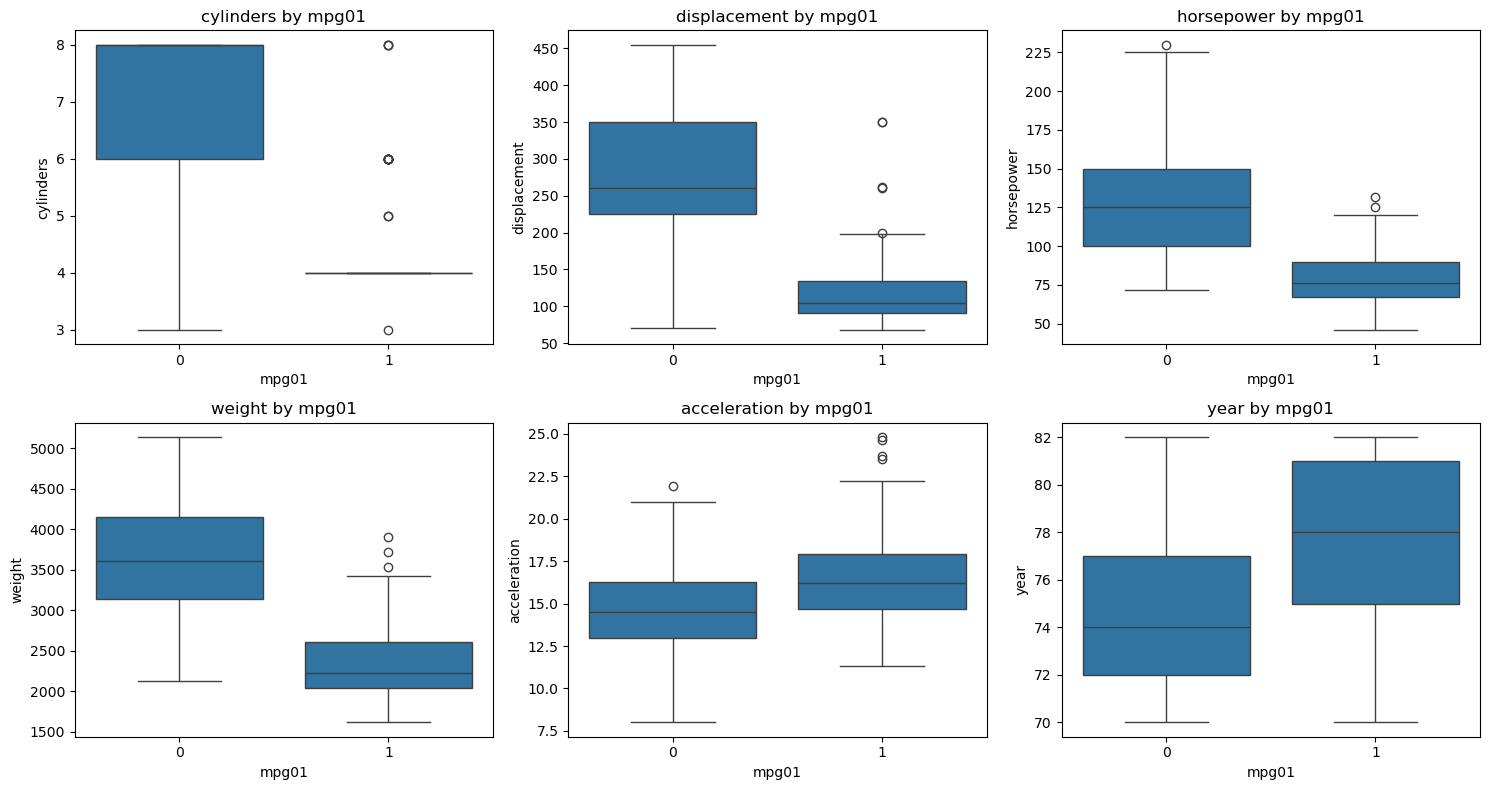

In [34]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='mpg01', y=feature, data=Auto, ax=axes[i])
    axes[i].set_title(f'{feature} by mpg01')

plt.tight_layout()
plt.show()

In [35]:
Auto.corr(numeric_only=True)['mpg01'].sort_values(ascending=False)

mpg01           1.000000
mpg             0.836939
origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
Name: mpg01, dtype: float64

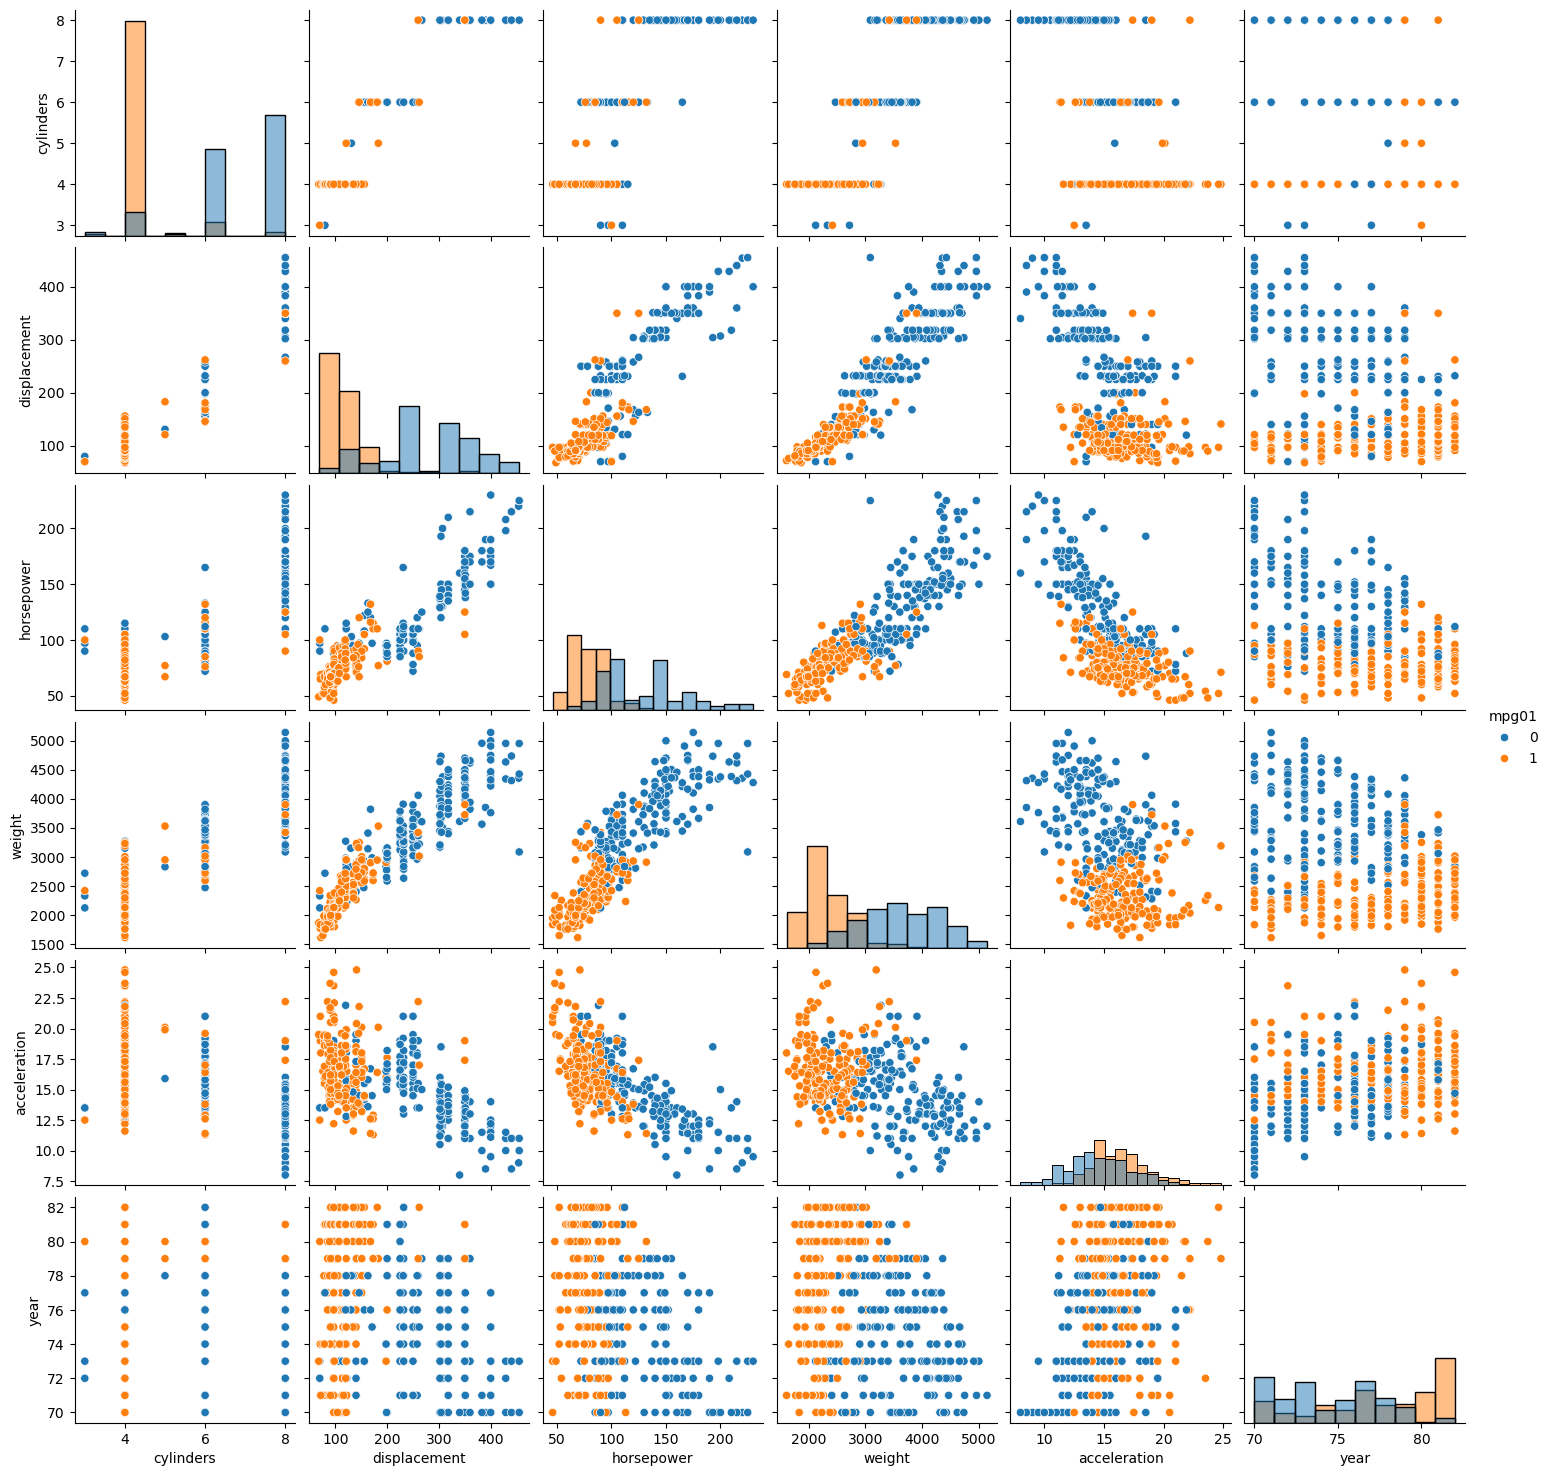

In [36]:
sns.pairplot(Auto[features + ['mpg01']], hue='mpg01', diag_kind='hist')
plt.show()

Both the boxplots and the correlation matrix point to the same conclusion: 
**cylinders, weight, displacement, and horsepower** are the strongest predictors 
of `mpg01`, each showing correlations with `mpg01` above $0.65$ in magnitude, 
and clear separation between the two `mpg01` groups in their boxplots with 
minimal overlap. All four are negatively correlated with `mpg01`, reflecting 
that heavier cars with larger, more powerful engines tend to have lower gas 
mileage.

**Year** and **origin** show a moderate positive relationship with `mpg01` 
($r = 0.430$ and $r = 0.514$, respectively), suggesting that cars from later 
model years and certain regions of origin are somewhat more likely to be 
fuel-efficient. **Acceleration** shows the weakest relationship ($r = 0.347$) 
and its boxplot shows substantial overlap between the two `mpg01` groups, 
making it the least useful predictor among the features examined.

Based on this exploration, **cylinders, weight, displacement, and horsepower** 
appear most useful for predicting `mpg01`, and will be prioritized in the 
classification models that follow.

### (c) Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
predictors = ['cylinders', 'weight', 'displacement', 'horsepower']

X = Auto[predictors]
y = Auto['mpg01']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(313, 4) (79, 4)


In [40]:
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
mpg01
1    0.507987
0    0.492013
Name: proportion, dtype: float64

Test:
mpg01
0    0.531646
1    0.468354
Name: proportion, dtype: float64


### (d) Linear Discriminant Analysis (LDA)

In [41]:
lda_auto = LinearDiscriminantAnalysis()
lda_auto.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [42]:
pred_lda_auto = lda_auto.predict(X_test)

In [43]:
conf_matrix_lda_auto = confusion_matrix(y_test, pred_lda_auto)
print(conf_matrix_lda_auto)

accuracy_lda_auto = (pred_lda_auto == y_test).mean()
test_error_lda_auto = 1 - accuracy_lda_auto

print(f"LDA Test accuracy: {accuracy_lda_auto:.4f}")
print(f"LDA Test error: {test_error_lda_auto:.4f}")

[[34  8]
 [ 0 37]]
LDA Test accuracy: 0.8987
LDA Test error: 0.1013


LDA using cylinders, weight, displacement, and horsepower as predictors 
achieved a test accuracy of $89.87\%$, corresponding to a test error of 
$10.13\%$. The confusion matrix shows that all errors were false positives 
(8 cars that were actually low-mpg were predicted as high-mpg), while there 
were zero false negatives (every actual high-mpg car was correctly identified). 
This is a substantial improvement over the results seen in Question 13, 
consistent with the much stronger correlations between these predictors and 
`mpg01` (all above $0.65$ in magnitude) compared to the weak lag-variable 
correlations in the Weekly dataset.

### (e) Quadratic Discriminant Analysis (QDA)

In [44]:
qda_auto = QuadraticDiscriminantAnalysis()
qda_auto.fit(X_train, y_train)

pred_qda_auto = qda_auto.predict(X_test)

conf_matrix_qda_auto = confusion_matrix(y_test, pred_qda_auto)
print(conf_matrix_qda_auto)

accuracy_qda_auto = (pred_qda_auto == y_test).mean()
test_error_qda_auto = 1 - accuracy_qda_auto

print(f"QDA Test accuracy: {accuracy_qda_auto:.4f}")
print(f"QDA Test error: {test_error_qda_auto:.4f}")

[[35  7]
 [ 1 36]]
QDA Test accuracy: 0.8987
QDA Test error: 0.1013


QDA achieved the same overall test accuracy as LDA ($89.87\%$, test error 
$10.13\%$), though the confusion matrix distributes errors slightly 
differently: QDA produced 7 false positives and 1 false negative, compared 
to LDA's 8 false positives and 0 false negatives. This suggests that, unlike 
in Question 13, the relationship between these predictors and `mpg01` is 
strong and consistent enough that the added flexibility of QDA's quadratic 
decision boundary neither helps nor hurts overall performance. Both linear 
(LDA) and quadratic (QDA) boundaries capture the underlying pattern about 
equally well here.

### (f) Logistic Regression

In [45]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

logit_auto = sm.Logit(y_train, X_train_sm)
results_auto = logit_auto.fit()
print(results_auto.summary())

Optimization terminated successfully.
         Current function value: 0.260845
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  mpg01   No. Observations:                  313
Model:                          Logit   Df Residuals:                      308
Method:                           MLE   Df Model:                            4
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.6236
Time:                        10:49:25   Log-Likelihood:                -81.644
converged:                       True   LL-Null:                       -216.92
Covariance Type:            nonrobust   LLR p-value:                 2.438e-57
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.2021      1.961      6.221      0.000       8.358      16.046
cylinders       -0.0140

In [46]:
pred_probs_auto = results_auto.predict(X_test_sm)
pred_labels_auto = (pred_probs_auto > 0.5).astype(int)

conf_matrix_logit_auto = confusion_matrix(y_test, pred_labels_auto)
print(conf_matrix_logit_auto)

accuracy_logit_auto = (pred_labels_auto == y_test).mean()
test_error_logit_auto = 1 - accuracy_logit_auto

print(f"Logistic Regression Test accuracy: {accuracy_logit_auto:.4f}")
print(f"Logistic Regression Test error: {test_error_logit_auto:.4f}")

[[35  7]
 [ 1 36]]
Logistic Regression Test accuracy: 0.8987
Logistic Regression Test error: 0.1013


Logistic regression achieved a test accuracy of $89.87\%$ (test error 
$10.13\%$), identical to both LDA and QDA. Its confusion matrix also exactly 
matched QDA's (7 false positives, 1 false negative). Despite this strong 
overall performance (Pseudo $R^2 = 0.624$), only **weight** ($p = 0.011$) and 
**horsepower** ($p = 0.003$) were statistically significant predictors, even 
though cylinders and displacement each showed strong individual correlations 
with `mpg01` in part (b). This is likely due to multicollinearity: cylinders, 
displacement, weight, and horsepower are all highly correlated with one 
another (larger engines tend to have more cylinders, greater displacement, 
more weight, and more horsepower simultaneously), so once weight and 
horsepower are included in the model, they capture most of the shared 
predictive signal, leaving little unique/independent contribution for 
cylinders and displacement.

### (g) Naive Bayes

In [47]:
nb_auto = GaussianNB()
nb_auto.fit(X_train, y_train)

pred_nb_auto = nb_auto.predict(X_test)

conf_matrix_nb_auto = confusion_matrix(y_test, pred_nb_auto)
print(conf_matrix_nb_auto)

accuracy_nb_auto = (pred_nb_auto == y_test).mean()
test_error_nb_auto = 1 - accuracy_nb_auto

print(f"Naive Bayes Test accuracy: {accuracy_nb_auto:.4f}")
print(f"Naive Bayes Test error: {test_error_nb_auto:.4f}")

[[34  8]
 [ 1 36]]
Naive Bayes Test accuracy: 0.8861
Naive Bayes Test error: 0.1139


Naive Bayes achieved a test accuracy of $88.61\%$ (test error $11.39\%$), 
slightly worse than LDA, QDA, and logistic regression, which all tied at 
$89.87\%$. This modest drop in performance is consistent with the 
multicollinearity identified in part (f): cylinders, displacement, weight, 
and horsepower are correlated with one another, which violates Naive Bayes's 
core assumption that predictors are independent given the class. While the 
impact here is small (roughly one additional misclassified observation out 
of 79 test cases), it illustrates how correlated predictors can mildly degrade 
Naive Bayes's performance relative to methods that don't require that 
independence assumption.

### Comparing All Methods

In [48]:
results_summary_auto = pd.DataFrame({
    'Method': ['LDA', 'QDA', 'Logistic Regression', 'Naive Bayes'],
    'Test Accuracy': [accuracy_lda_auto, accuracy_qda_auto, accuracy_logit_auto, accuracy_nb_auto],
    'Test Error': [test_error_lda_auto, test_error_qda_auto, test_error_logit_auto, test_error_nb_auto]
})

results_summary_auto['Test Accuracy'] = results_summary_auto['Test Accuracy'].round(4)
results_summary_auto['Test Error'] = results_summary_auto['Test Error'].round(4)
results_summary_auto = results_summary_auto.sort_values('Test Error').reset_index(drop=True)

results_summary_auto.style.hide(axis='index')

Method,Test Accuracy,Test Error
LDA,0.898700,0.101300
QDA,0.898700,0.101300
Logistic Regression,0.898700,0.101300
Naive Bayes,0.886100,0.113900


Across all four methods, LDA, QDA, and logistic regression tied for the best 
performance, each achieving a test accuracy of $89.87\%$ (test error $10.13\%$). 
Naive Bayes performed slightly worse, at $88.61\%$ accuracy (test error 
$11.39\%$), likely due to the multicollinearity among cylinders, displacement, 
weight, and horsepower violating its independence assumption. Overall, these 
results confirm that cylinders, weight, displacement, and horsepower are 
strong, reliable predictors of `mpg01`, with all methods achieving well over 
$88\%$ accuracy regardless of the underlying modeling assumptions.

### (h) K-Nearest Neighbors (KNN)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
knn_auto_results = []
for k in [1, 3, 5, 7, 9, 11, 15, 21, 25]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    acc_k = (pred_k == y_test).mean()
    err_k = 1 - acc_k
    knn_auto_results.append({'K': k, 'Test Accuracy': round(acc_k, 4), 'Test Error': round(err_k, 4)})

knn_auto_results_df = pd.DataFrame(knn_auto_results)
knn_auto_results_df

,K,Test Accuracy,Test Error
0,1,0.8608,0.1392
1,3,0.8987,0.1013
2,5,0.8987,0.1013
3,7,0.8861,0.1139
4,9,0.8861,0.1139
5,11,0.8861,0.1139
6,15,0.8987,0.1013
7,21,0.8987,0.1013
8,25,0.8987,0.1013


In [51]:
best_row = knn_auto_results_df.loc[knn_auto_results_df['Test Error'].idxmin()]
print(f"Best K: {int(best_row['K'])}, Test Error: {best_row['Test Error']}")

Best K: 3, Test Error: 0.1013


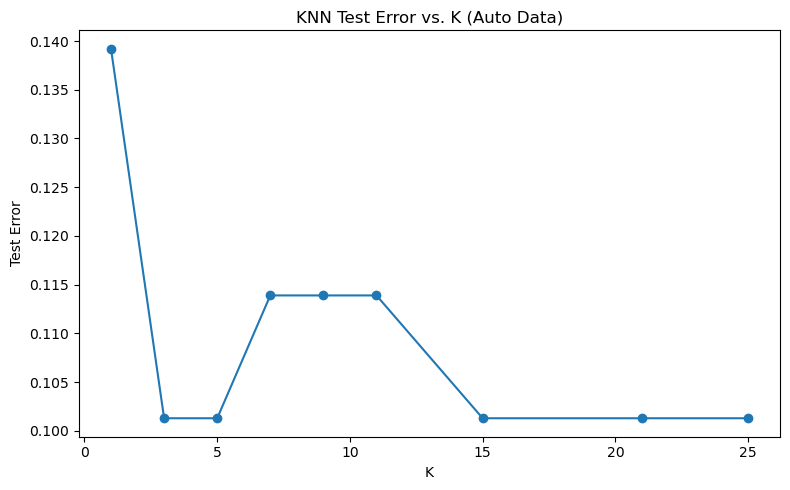

In [52]:
plt.figure(figsize=(8,5))
plt.plot(knn_auto_results_df['K'], knn_auto_results_df['Test Error'], marker='o')
plt.xlabel('K')
plt.ylabel('Test Error')
plt.title('KNN Test Error vs. K (Auto Data)')
plt.tight_layout()
plt.show()

Testing KNN across a range of $K$ values (1, 3, 5, 7, 9, 11, 15, 21, and 25) 
using cylinders, weight, displacement, and horsepower (scaled) as predictors, 
the lowest test error achieved was $10.13\%$ (test accuracy $89.87\%$), tied 
across $K = 3, 5, 15, 21,$ and $25$. The worst performance occurred at $K=1$ 
($13.92\%$ test error), consistent with $K=1$ being the highest-variance, most 
overfitting-prone version of KNN. Among the tied values, $K=3$ is preferred as 
the smallest $K$ achieving the best performance, balancing model simplicity 
with predictive accuracy.

Notably, KNN's best test error ($10.13\%$) matches the results obtained by 
LDA, QDA, and logistic regression, suggesting that all of these methods 
capture the underlying relationship between engine-related features and 
`mpg01` about equally well on this dataset.

# Q16
Using the Boston data set, fit classification models in order to predict
whether a given suburb has a crime rate above or below the median.
Explore logistic regression, LDA, naive Bayes, and KNN models using
various subsets of the predictors. Describe your findings.
Hint: You will have to create the response variable yourself, using the
variables that are contained in the Boston data set.

### Creating the crim01 Response Variable

In [53]:
Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [54]:
crim_median = Boston['crim'].median()
Boston['crim01'] = (Boston['crim'] > crim_median).astype(int)

Boston[['crim', 'crim01']].head(10)

,crim,crim01
0,0.00632,0
1,0.02731,0
2,0.02729,0
3,0.03237,0
4,0.06905,0
5,0.02985,0
6,0.08829,0
7,0.14455,0
8,0.21124,0
9,0.17004,0


In [55]:
Boston['crim01'].value_counts()

crim01
0    253
1    253
Name: count, dtype: int64

### Exploratory Analysis

In [56]:
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv', 'crim01'],
      dtype='object')

In [57]:
Boston.corr(numeric_only=True)['crim01'].abs().sort_values(ascending=False)

crim01     1.000000
nox        0.723235
rad        0.619786
dis        0.616342
age        0.613940
tax        0.608741
indus      0.603260
lstat      0.453263
zn         0.436151
crim       0.409395
medv       0.263017
ptratio    0.253568
rm         0.156372
chas       0.070097
Name: crim01, dtype: float64

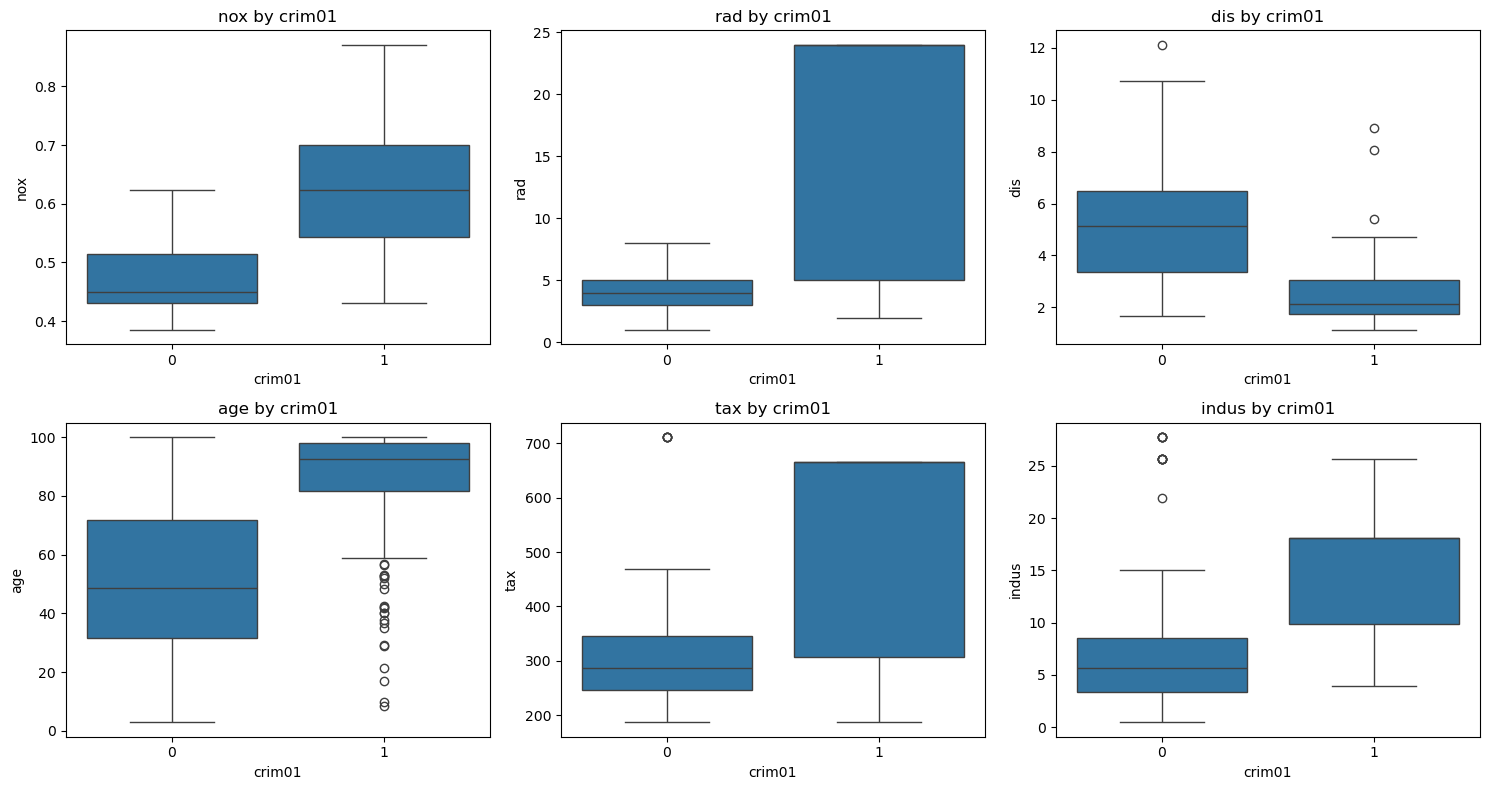

In [58]:
top_features = ['nox', 'rad', 'dis', 'age', 'tax', 'indus']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='crim01', y=feature, data=Boston, ax=axes[i])
    axes[i].set_title(f'{feature} by crim01')

plt.tight_layout()
plt.show()

The boxplots confirm the correlation rankings: **nox, rad, dis, age, tax,** 
and **indus** all show clear separation between the two `crim01` groups, with 
little to no overlap in most cases. Suburbs with higher crime rates tend to 
have worse air quality (higher nox), easier highway access (higher rad), 
closer proximity to employment centers (lower dis), older housing stock 
(higher age), higher property taxes (higher tax), and more industrial land 
use (higher indus). Notably, `rad` and `tax` show much wider spread in the 
high-crime group compared to the low-crime group, suggesting these suburbs 
are a more heterogeneous group for those two variables rather than uniformly 
shifted higher.

### Train/Test Split

In [59]:
predictors_boston = ['nox', 'rad', 'dis', 'age', 'tax', 'indus']

X_boston = Boston[predictors_boston]
y_boston = Boston['crim01']

In [60]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=42
)

print(X_train_b.shape, X_test_b.shape)

(404, 6) (102, 6)


In [61]:
print("Train:")
print(y_train_b.value_counts(normalize=True))
print("\nTest:")
print(y_test_b.value_counts(normalize=True))

Train:
crim01
1    0.502475
0    0.497525
Name: proportion, dtype: float64

Test:
crim01
0    0.509804
1    0.490196
Name: proportion, dtype: float64


### Logistic Regression

In [62]:
#Logistic Regression
X_train_b_sm = sm.add_constant(X_train_b)
X_test_b_sm = sm.add_constant(X_test_b)

logit_boston = sm.Logit(y_train_b, X_train_b_sm)
results_boston = logit_boston.fit()
print(results_boston.summary())

pred_probs_boston = results_boston.predict(X_test_b_sm)
pred_labels_boston = (pred_probs_boston > 0.5).astype(int)

conf_matrix_logit_boston = confusion_matrix(y_test_b, pred_labels_boston)
print(conf_matrix_logit_boston)

accuracy_logit_boston = (pred_labels_boston == y_test_b).mean()
test_error_logit_boston = 1 - accuracy_logit_boston
print(f"Logistic Regression Test accuracy: {accuracy_logit_boston:.4f}")
print(f"Logistic Regression Test error: {test_error_logit_boston:.4f}")

Optimization terminated successfully.
         Current function value: 0.245367
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 crim01   No. Observations:                  404
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            6
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.6460
Time:                        10:49:29   Log-Likelihood:                -99.128
converged:                       True   LL-Null:                       -280.03
Covariance Type:            nonrobust   LLR p-value:                 4.524e-75
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -24.7464      4.273     -5.791      0.000     -33.122     -16.371
nox           41.7638      7

Logistic regression using nox, rad, dis, age, tax, and indus achieved a test accuracy of $86.27\%$ (test error $13.73\%$). Among these predictors, **nox**, **rad**, and **tax** were statistically significant ($p < 0.05$), while dis, age, and indus were not. The model also produced a quasi-separation warning, indicating that roughly $28\%$ of observations could be perfectly predicted by the model — likely driven by extreme values in `rad`, where high-crime suburbs cluster at very high highway-accessibility values. This can inflate coefficient estimates (notably nox's coefficient of $41.76$) and makes the reported p-values somewhat less reliable, though the model's overall predictive accuracy remains strong.

### Linear Discriminant Analysis (LDA)

In [63]:
# LDA
lda_boston = LinearDiscriminantAnalysis()
lda_boston.fit(X_train_b, y_train_b)
pred_lda_boston = lda_boston.predict(X_test_b)

conf_matrix_lda_boston = confusion_matrix(y_test_b, pred_lda_boston)
print(conf_matrix_lda_boston)

accuracy_lda_boston = (pred_lda_boston == y_test_b).mean()
test_error_lda_boston = 1 - accuracy_lda_boston
print(f"LDA Test accuracy: {accuracy_lda_boston:.4f}")
print(f"LDA Test error: {test_error_lda_boston:.4f}")

[[47  5]
 [13 37]]
LDA Test accuracy: 0.8235
LDA Test error: 0.1765


LDA achieved a test accuracy of $82.35\%$ (test error $17.65\%$), somewhat lower than logistic regression's $86.27\%$. Both methods produced identical true negative and false positive counts, but LDA missed more actual high-crime suburbs (13 false negatives vs. 9 for logistic regression). This gap may stem from LDA's assumption that predictors are normally distributed with equal variance across classes. That assumption that appears questionable given the boxplots in the exploratory analysis, where `rad` and `tax` showed noticeably wider and more skewed spread in the high-crime group compared to the low-crime group.

### Naive Bayes

In [64]:
# Naive Bayes
nb_boston = GaussianNB()
nb_boston.fit(X_train_b, y_train_b)
pred_nb_boston = nb_boston.predict(X_test_b)

conf_matrix_nb_boston = confusion_matrix(y_test_b, pred_nb_boston)
print(conf_matrix_nb_boston)

accuracy_nb_boston = (pred_nb_boston == y_test_b).mean()
test_error_nb_boston = 1 - accuracy_nb_boston
print(f"Naive Bayes Test accuracy: {accuracy_nb_boston:.4f}")
print(f"Naive Bayes Test error: {test_error_nb_boston:.4f}")

[[47  5]
 [12 38]]
Naive Bayes Test accuracy: 0.8333
Naive Bayes Test error: 0.1667


Naive Bayes achieved a test accuracy of $83.33\%$ (test error $16.67\%$), close to LDA's performance and slightly better, but still behind logistic regression. All three methods agree exactly on classifying the low-crime suburbs (47 true negatives, 5 false positives in each case), with the differences arising entirely from how well each method identifies actual high-crime suburbs. Naive Bayes's underlying independence assumption is likely violated here too, since several predictors (nox, rad, tax, indus) are related to industrial land use and would reasonably be correlated with one another, similar to the multicollinearity observed in Question 14.

### K-Nearest Neighbors (KNN)

In [65]:
# KNN
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

knn_boston_results = []
for k in [1, 3, 5, 7, 9, 11, 15, 21, 25]:
    knn_b = KNeighborsClassifier(n_neighbors=k)
    knn_b.fit(X_train_b_scaled, y_train_b)
    pred_k_b = knn_b.predict(X_test_b_scaled)
    acc_k_b = (pred_k_b == y_test_b).mean()
    err_k_b = 1 - acc_k_b
    knn_boston_results.append({'K': k, 'Test Accuracy': round(acc_k_b, 4), 'Test Error': round(err_k_b, 4)})

knn_boston_results_df = pd.DataFrame(knn_boston_results)
knn_boston_results_df

,K,Test Accuracy,Test Error
0,1,0.9412,0.0588
1,3,0.9118,0.0882
2,5,0.9118,0.0882
3,7,0.9118,0.0882
4,9,0.8922,0.1078
5,11,0.8824,0.1176
6,15,0.8725,0.1275
7,21,0.8627,0.1373
8,25,0.8824,0.1176


KNN substantially outperformed all other methods, with $K=1$ achieving the 
best result overall: $94.12\%$ test accuracy ($5.88\%$ test error). Accuracy 
steadily declined as $K$ increased, suggesting the boundary between high-crime 
and low-crime suburbs is complex and possibly non-linear, favoring a highly 
flexible method like KNN with small $K$ over the linear boundaries assumed by 
logistic regression and LDA. This contrasts with Question 13, where $K=1$ 
performed worst; there, the weak true signal in the data meant a highly 
flexible model mostly captured noise, whereas here, the strong, well-separated 
predictors identified in the exploratory analysis provide a clean enough 
signal that even the most flexible KNN model generalizes well rather than 
overfitting.

### Comparing All Methods

In [66]:
results_summary_boston = pd.DataFrame({
    'Method': ['Logistic Regression', 'LDA', 'Naive Bayes', 'KNN (K=1)'],
    'Test Accuracy': [accuracy_logit_boston, accuracy_lda_boston, accuracy_nb_boston, 0.9412],
    'Test Error': [test_error_logit_boston, test_error_lda_boston, test_error_nb_boston, 0.0588]
})

results_summary_boston['Test Accuracy'] = results_summary_boston['Test Accuracy'].round(4)
results_summary_boston['Test Error'] = results_summary_boston['Test Error'].round(4)
results_summary_boston = results_summary_boston.sort_values('Test Error').reset_index(drop=True)

results_summary_boston.style.hide(axis='index')

Method,Test Accuracy,Test Error
KNN (K=1),0.941200,0.058800
Logistic Regression,0.862700,0.137300
Naive Bayes,0.833300,0.166700
LDA,0.823500,0.176500


## Summary of Findings

Across all four classification methods, **KNN with $K=1$** provided the best 
performance on this dataset, achieving $94.12\%$ test accuracy ($5.88\%$ test 
error) using the six predictors most associated with `crim01` in the 
exploratory analysis: nox, rad, dis, age, tax, and indus. Logistic regression 
followed at $86.27\%$, with naive Bayes and LDA trailing further behind at 
$83.33\%$ and $82.35\%$, respectively.

This ordering reflects the nature of the relationship between these predictors 
and crime rate. The exploratory boxplots showed strong, often non-linear 
separation between high- and low-crime suburbs. Particularly for `rad`, 
where high-crime suburbs clustered at extreme highway-accessibility values 
rather than following a smooth linear trend. This kind of clustered structure 
favors a highly flexible, assumption-free method like KNN over methods that 
assume linear decision boundaries (logistic regression, LDA) or independence 
between predictors (naive Bayes). Consistent with this, KNN's accuracy 
declined steadily as $K$ increased, suggesting the true classification 
boundary is complex enough that even modest smoothing hurts performance. The 
opposite pattern from Question 13, where a weak true signal caused $K=1$ to 
overfit and perform worst.

Among the three parametric methods, logistic regression outperformed both LDA 
and naive Bayes, though its results should be interpreted with some caution 
given the quasi-separation warning noted during fitting, which suggested that 
roughly $28\%$ of observations could be perfectly predicted and may have 
inflated some coefficient estimates. LDA's comparatively weaker performance 
is consistent with its assumption of normally distributed, equal-variance 
predictors across classes, an assumption the exploratory analysis suggested 
was likely violated, particularly for `rad` and `tax`.

Overall, these results suggest that suburb crime rate is closely tied to 
industrial and infrastructure characteristics (air pollution, highway access, 
property tax, industrial land use), and that the relationship between these 
factors and crime is complex enough that flexible, non-parametric methods 
like KNN capture it more effectively than linear or distribution-based methods.